In [120]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import *
from sklearn.model_selection import *
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import *
from pprint import pprint

In [121]:
pnas_normal_readcounts = pd.read_csv('data/reads/pnas_normal_tpm.txt', sep='\t')
pnas_readcounts_96 = pd.read_csv('data/reads/pnas_tpm_96_nodup.txt', sep='\t', header=None)

pnas_readcounts_96 = pnas_readcounts_96.set_index(pnas_readcounts_96.columns[0])

print(pnas_normal_readcounts.shape)
print(pnas_readcounts_96.shape)

n_normal = pnas_normal_readcounts.shape[1]
n_cancer = pnas_readcounts_96.shape[1]

data = pd.concat([pnas_normal_readcounts, pnas_readcounts_96], axis=1).T

print(len(data), n_normal + n_cancer)

(60675, 32)
(60675, 96)
128 128


In [122]:
threshold = 0.1
min_sample_fraction = 0.20

min_samples = int(len(data) * min_sample_fraction)

gene_mask = (data > threshold).sum(axis=0) >= min_samples

filtered_data = data.loc[:, gene_mask]

print(filtered_data.shape)

(128, 43027)


In [123]:
filtered_data["cancer_status"] = [0] * n_normal + [1] * n_cancer

print(filtered_data)
print(filtered_data.shape)

    ENSG00000000003  ENSG00000000005  ENSG00000000419  ENSG00000000457  \
N1        26.432148        24.817762        66.208114         8.127159   
N2        17.260895         5.402219         0.000000         6.318156   
N3         0.000000         7.557640        10.081027        15.910242   
N4        69.795165         0.000000         0.000000        15.328639   
N5        19.331552         0.000000        18.158365        19.105460   
..              ...              ...              ...              ...   
92         0.000000         0.000000       179.178412        83.788404   
93        38.189128         5.976111        15.942897        18.172309   
94        15.608352         6.280734         0.000000         2.938248   
95        51.519267       241.863225         0.000000        14.547636   
96        30.805593         0.000000         0.000000        10.148436   

    ENSG00000000460  ENSG00000000938  ENSG00000000971  ENSG00000001036  \
N1         8.035515        16.102255 

/var/folders/y5/gxfz0jhs2t3_xl9dj050660m0000gn/T/ipykernel_23198/1599123068.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data["cancer_status"] = [0] * n_normal + [1] * n_cancer


# Whole Dataset

In [124]:
scaler = MinMaxScaler()
X = filtered_data.drop(columns=["cancer_status"])
y = filtered_data["cancer_status"]
X_scaled = scaler.fit_transform(X)

## Logistic Regression

LR Model Cross-validation average score: 0.8828571428571429
Accuracy: 0.8461538461538461
Precision: 0.8181818181818182
Recall: 1.0
F1 Score: 0.9
ROC-AUC Score: 0.9652777777777778
Confusion Matrix:
[[ 4  4]
 [ 0 18]]


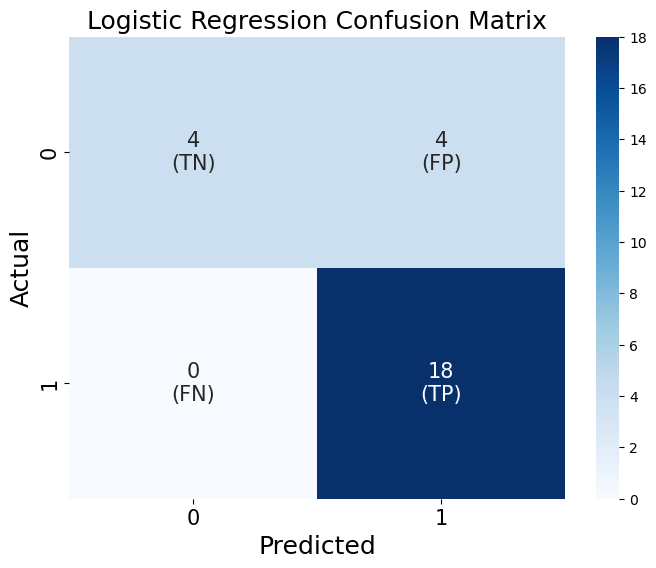

In [125]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42)

LR_Model = LogisticRegression()

LR_cross_scores = cross_val_score(LR_Model, X_train, y_train, cv=5)
print(f'LR Model Cross-validation average score: {LR_cross_scores.mean()}')

# Train the model
LR_Model.fit(X_train, y_train)

# Predict on the test set
y_pred = LR_Model.predict(X_test)
y_pred_proba = LR_Model.predict_proba(X_test)[:, 1]

# Evaluation metrics
LR_accuracy = accuracy_score(y_test, y_pred)
LR_precision = precision_score(y_test, y_pred)
LR_recall = recall_score(y_test, y_pred)
LR_f1 = f1_score(y_test, y_pred)
LR_roc_auc = roc_auc_score(y_test, y_pred_proba)
LR_conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {LR_accuracy}')
print(f'Precision: {LR_precision}')
print(f'Recall: {LR_recall}')
print(f'F1 Score: {LR_f1}')
print(f'ROC-AUC Score: {LR_roc_auc}')
print(f'Confusion Matrix:\n{LR_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{LR_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(LR_conf_matrix.shape[1])] 
                              for i in range(LR_conf_matrix.shape[0])])

value, counts = np.unique(y_test, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(LR_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Logistic Regression Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

### Randomized Search

In [126]:
print('Parameters currently in use:\n')
pprint(LR_Model.get_params())

Parameters currently in use:

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'auto',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}


In [127]:
C = [0.001, 0.01, 0.1, 1, 10, 100]

penalty = ['l1', 'l2', 'elasticnet']

solver = ['liblinear', 'saga', 'lbfgs']

class_weight = [None, 'balanced']

max_iter = [100, 500, 1000, 2000]

l1_ratio = [0.1, 0.5, 0.9]

# Create the random grid
random_grid = {'C': C,
               'penalty': penalty,
               'solver': solver,
               'class_weight': class_weight,
               'max_iter': max_iter,
               'l1_ratio': l1_ratio}
pprint(random_grid)

{'C': [0.001, 0.01, 0.1, 1, 10, 100],
 'class_weight': [None, 'balanced'],
 'l1_ratio': [0.1, 0.5, 0.9],
 'max_iter': [100, 500, 1000, 2000],
 'penalty': ['l1', 'l2', 'elasticnet'],
 'solver': ['liblinear', 'saga', 'lbfgs']}


In [128]:
LR_random = RandomizedSearchCV(estimator = LR_Model, param_distributions = random_grid, n_iter=50, cv = 5, scoring='accuracy', verbose=10, random_state=42, n_jobs = -1)
LR_random.fit(X_train,y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 2/5; 1/50] START C=0.1, class_weight=balanced, l1_ratio=0.5, max_iter=1000, penalty=l2, solver=saga
[CV 4/5; 1/50] START C=0.1, class_weight=balanced, l1_ratio=0.5, max_iter=1000, penalty=l2, solver=saga
[CV 5/5; 1/50] START C=0.1, class_weight=balanced, l1_ratio=0.5, max_iter=1000, penalty=l2, solver=saga
[CV 2/5; 2/50] START C=0.01, class_weight=balanced, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=saga
[CV 1/5; 2/50] START C=0.01, class_weight=balanced, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=saga
[CV 3/5; 1/50] START C=0.1, class_weight=balanced, l1_ratio=0.5, max_iter=1000, penalty=l2, solver=saga
[CV 1/5; 1/50] START C=0.1, class_weight=balanced, l1_ratio=0.5, max_iter=1000, penalty=l2, solver=saga
[CV 3/5; 2/50] START C=0.01, class_weight=balanced, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=saga


/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-

[CV 3/5; 2/50] END C=0.01, class_weight=balanced, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=saga;, score=1.000 total time=   1.9s
[CV 1/5; 2/50] END C=0.01, class_weight=balanced, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=saga;, score=0.857 total time=   2.1s
[CV 4/5; 2/50] START C=0.01, class_weight=balanced, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=saga


/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


[CV 5/5; 2/50] START C=0.01, class_weight=balanced, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=saga
[CV 2/5; 2/50] END C=0.01, class_weight=balanced, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=saga;, score=0.810 total time=   2.2s
[CV 1/5; 3/50] START C=1, class_weight=None, l1_ratio=0.9, max_iter=1000, penalty=elasticnet, solver=saga
[CV 4/5; 2/50] END C=0.01, class_weight=balanced, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=saga;, score=0.950 total time=   1.7s
[CV 2/5; 3/50] START C=1, class_weight=None, l1_ratio=0.9, max_iter=1000, penalty=elasticnet, solver=saga
[CV 5/5; 2/50] END C=0.01, class_weight=balanced, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=saga;, score=0.800 total time=   1.8s
[CV 3/5; 3/50] START C=1, class_weight=None, l1_ratio=0.9, max_iter=1000, penalty=elasticnet, solver=saga
[CV 4/5; 1/50] END C=0.1, class_weight=balanced, l1_ratio=0.5, max_iter=1000, penalty=l2, solver=saga;, score=0.950 total time=   5.4s
[CV 4/5; 3/50] START C=1, class_we

...

[CV 1/5; 50/50] END C=10, class_weight=None, l1_ratio=0.5, max_iter=500, penalty=l2, solver=lbfgs;, score=0.857 total time=   1.1s
[CV 5/5; 42/50] END C=10, class_weight=None, l1_ratio=0.5, max_iter=100, penalty=l2, solver=saga;, score=0.800 total time=   4.7s
[CV 2/5; 50/50] END C=10, class_weight=None, l1_ratio=0.5, max_iter=500, penalty=l2, solver=lbfgs;, score=0.857 total time=   1.5s
[CV 4/5; 50/50] END C=10, class_weight=None, l1_ratio=0.5, max_iter=500, penalty=l2, solver=lbfgs;, score=0.950 total time=   1.4s
[CV 3/5; 50/50] END C=10, class_weight=None, l1_ratio=0.5, max_iter=500, penalty=l2, solver=lbfgs;, score=1.000 total time=   1.5s
[CV 5/5; 50/50] END C=10, class_weight=None, l1_ratio=0.5, max_iter=500, penalty=l2, solver=lbfgs;, score=0.800 total time=   1.1s


/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:378: FitFailedWarning: 
110 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
45 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_scor

[CV 4/5; 19/50] END C=1, class_weight=None, l1_ratio=0.1, max_iter=1000, penalty=elasticnet, solver=saga;, score=0.950 total time=  56.4s
[CV 5/5; 19/50] END C=1, class_weight=None, l1_ratio=0.1, max_iter=1000, penalty=elasticnet, solver=saga;, score=0.800 total time=  56.1s


/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


RandomizedSearchCV(cv=5, estimator=LogisticRegression(), n_iter=50, n_jobs=-1,
                   param_distributions={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                                        'class_weight': [None, 'balanced'],
                                        'l1_ratio': [0.1, 0.5, 0.9],
                                        'max_iter': [100, 500, 1000, 2000],
                                        'penalty': ['l1', 'l2', 'elasticnet'],
                                        'solver': ['liblinear', 'saga',
                                                   'lbfgs']},
                   random_state=42, scoring='accuracy', verbose=10)

In [129]:
LR_random.best_params_

{'solver': 'saga',
 'penalty': 'elasticnet',
 'max_iter': 500,
 'l1_ratio': 0.9,
 'class_weight': 'balanced',
 'C': 0.1}

In [130]:
best_LR = LR_random.best_estimator_

Accuracy: 0.9230769230769231
Precision: 0.9
Recall: 1.0
F1 Score: 0.9473684210526316
ROC-AUC Score: 1.0
Confusion Matrix:
[[ 6  2]
 [ 0 18]]


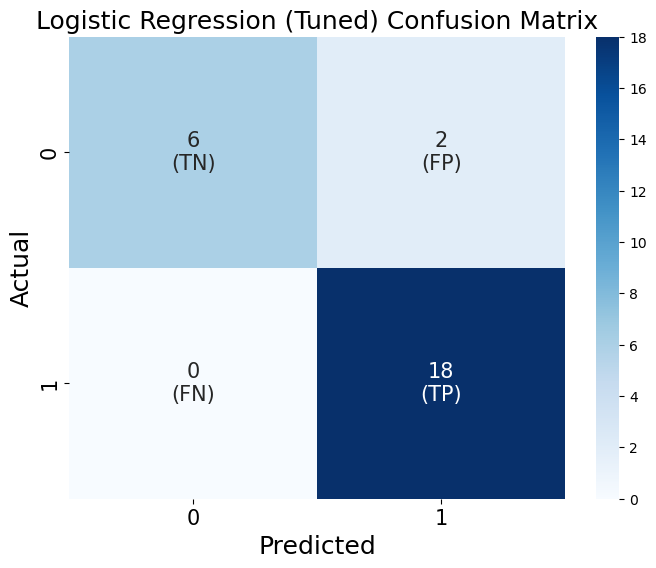

In [131]:
# Predict on the test set
y_pred = best_LR.predict(X_test)
y_pred_proba = best_LR.predict_proba(X_test)[:, 1]

# Evaluation metrics
LR_rand_accuracy = accuracy_score(y_test, y_pred)
LR_rand_precision = precision_score(y_test, y_pred)
LR_rand_recall = recall_score(y_test, y_pred)
LR_rand_f1 = f1_score(y_test, y_pred)
LR_rand_roc_auc = roc_auc_score(y_test, y_pred_proba)
LR_rand_conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {LR_rand_accuracy}')
print(f'Precision: {LR_rand_precision}')
print(f'Recall: {LR_rand_recall}')
print(f'F1 Score: {LR_rand_f1}')
print(f'ROC-AUC Score: {LR_rand_roc_auc}')
print(f'Confusion Matrix:\n{LR_rand_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{LR_rand_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(LR_rand_conf_matrix.shape[1])] 
                              for i in range(LR_rand_conf_matrix.shape[0])])

value, counts = np.unique(y_test, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(LR_rand_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Logistic Regression (Tuned) Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

## Random Forest

RF Model Cross-validation average score: 0.8928571428571429
Accuracy: 0.8461538461538461
Precision: 0.8181818181818182
Recall: 1.0
F1 Score: 0.9
ROC-AUC Score: 0.9791666666666666
Confusion Matrix:
[[ 4  4]
 [ 0 18]]


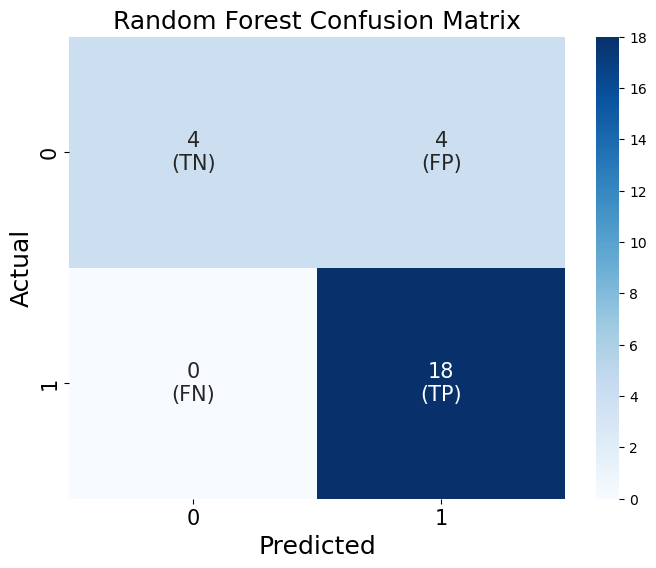

In [149]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42)

RF_Model = RandomForestClassifier()

RF_cross_scores = cross_val_score(RF_Model, X_train, y_train, cv=5)
print(f'RF Model Cross-validation average score: {RF_cross_scores.mean()}')

# Train the model
RF_Model.fit(X_train, y_train)

# Predict on the test set
y_pred = RF_Model.predict(X_test)
y_pred_proba = RF_Model.predict_proba(X_test)[:, 1]

# Evaluation metrics
RF_accuracy = accuracy_score(y_test, y_pred)
RF_precision = precision_score(y_test, y_pred)
RF_recall = recall_score(y_test, y_pred)
RF_f1 = f1_score(y_test, y_pred)
RF_roc_auc = roc_auc_score(y_test, y_pred_proba)
RF_conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {RF_accuracy}')
print(f'Precision: {RF_precision}')
print(f'Recall: {RF_recall}')
print(f'F1 Score: {RF_f1}')
print(f'ROC-AUC Score: {RF_roc_auc}')
print(f'Confusion Matrix:\n{RF_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{RF_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(RF_conf_matrix.shape[1])] 
                              for i in range(RF_conf_matrix.shape[0])])

value, counts = np.unique(y_test, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(RF_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Random Forest Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

### Randomized Search

In [150]:
print('Parameters currently in use:\n')
pprint(RF_Model.get_params())

Parameters currently in use:

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}


In [151]:
n_estimators = [100, 200, 500, 1000]

max_depth = [None, 10, 20, 50, 100]

min_samples_split = [2, 5, 10, 20]

min_samples_leaf = [1, 2, 4, 8]

max_features = ['sqrt', 'log2', None]

bootstrap = [True, False]

class_weight = [None, 'balanced', 'balanced_subsample']

criterion = ['gini', 'entropy', 'log_loss']

# Create the random grid
random_grid = {'n_estimators': n_estimators,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'max_features': max_features,
               'bootstrap': bootstrap,
               'class_weight': class_weight,
               'criterion': criterion}
pprint(random_grid)

{'bootstrap': [True, False],
 'class_weight': [None, 'balanced', 'balanced_subsample'],
 'criterion': ['gini', 'entropy', 'log_loss'],
 'max_depth': [None, 10, 20, 50, 100],
 'max_features': ['sqrt', 'log2', None],
 'min_samples_leaf': [1, 2, 4, 8],
 'min_samples_split': [2, 5, 10, 20],
 'n_estimators': [100, 200, 500, 1000]}


In [152]:
RF_random = RandomizedSearchCV(estimator = RF_Model, param_distributions = random_grid, n_iter=50, cv = 5, scoring='accuracy', verbose=10, random_state=42, n_jobs = -1)
RF_random.fit(X_train,y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 2/5; 2/50] START bootstrap=True, class_weight=None, criterion=gini, max_depth=100, max_features=log2, min_samples_leaf=2, min_samples_split=20, n_estimators=100
[CV 4/5; 1/50] START bootstrap=False, class_weight=balanced_subsample, criterion=entropy, max_depth=20, max_features=sqrt, min_samples_leaf=8, min_samples_split=2, n_estimators=1000
[CV 2/5; 1/50] START bootstrap=False, class_weight=balanced_subsample, criterion=entropy, max_depth=20, max_features=sqrt, min_samples_leaf=8, min_samples_split=2, n_estimators=1000
[CV 3/5; 2/50] START bootstrap=True, class_weight=None, criterion=gini, max_depth=100, max_features=log2, min_samples_leaf=2, min_samples_split=20, n_estimators=100
[CV 5/5; 1/50] START bootstrap=False, class_weight=balanced_subsample, criterion=entropy, max_depth=20, max_features=sqrt, min_samples_leaf=8, min_samples_split=2, n_estimators=1000
[CV 1/5; 2/50] START bootstrap=True, class_weight=None, criter

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=50,
                   n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'class_weight': [None, 'balanced',
                                                         'balanced_subsample'],
                                        'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': [None, 10, 20, 50, 100],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4, 8],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'n_estimators': [100, 200, 500, 1000]},
                   random_state=42, scoring='accuracy', verbose=10)

In [153]:
RF_random.best_params_

{'n_estimators': 100,
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_features': None,
 'max_depth': 50,
 'criterion': 'log_loss',
 'class_weight': None,
 'bootstrap': False}

In [154]:
best_RF = RF_random.best_estimator_

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC Score: 1.0
Confusion Matrix:
[[ 8  0]
 [ 0 18]]


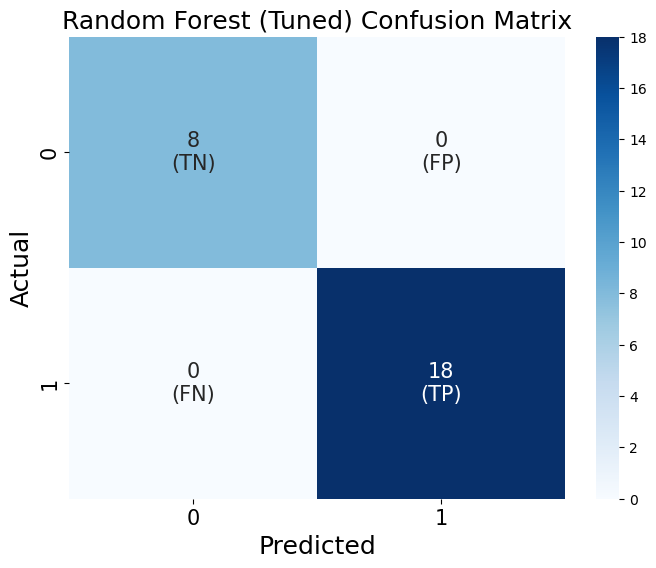

In [155]:
# Predict on the test set
y_pred = best_RF.predict(X_test)
y_pred_proba = best_RF.predict_proba(X_test)[:, 1]

# Evaluation metrics
RF_rand_accuracy = accuracy_score(y_test, y_pred)
RF_rand_precision = precision_score(y_test, y_pred)
RF_rand_recall = recall_score(y_test, y_pred)
RF_rand_f1 = f1_score(y_test, y_pred)
RF_rand_roc_auc = roc_auc_score(y_test, y_pred_proba)
RF_rand_conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {RF_rand_accuracy}')
print(f'Precision: {RF_rand_precision}')
print(f'Recall: {RF_rand_recall}')
print(f'F1 Score: {RF_rand_f1}')
print(f'ROC-AUC Score: {RF_rand_roc_auc}')
print(f'Confusion Matrix:\n{RF_rand_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{RF_rand_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(RF_rand_conf_matrix.shape[1])] 
                              for i in range(RF_rand_conf_matrix.shape[0])])

value, counts = np.unique(y_test, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(RF_rand_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Random Forest (Tuned) Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

## Naive Bayes

NB Model Cross-validation average score: 0.7647619047619048
Accuracy: 0.6923076923076923
Precision: 0.6923076923076923
Recall: 1.0
F1 Score: 0.8181818181818181
ROC-AUC Score: 0.5
Confusion Matrix:
[[ 0  8]
 [ 0 18]]


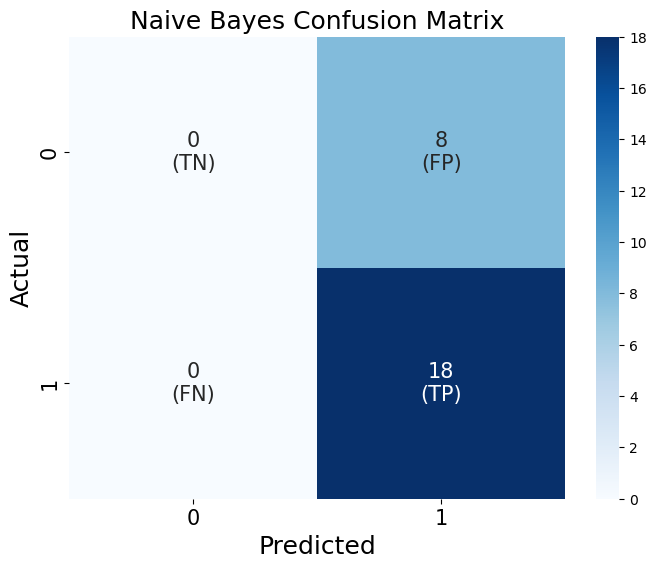

In [156]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42)

NB_Model = GaussianNB()

NB_cross_scores = cross_val_score(NB_Model, X_train, y_train, cv=5)
print(f'NB Model Cross-validation average score: {NB_cross_scores.mean()}')

# Train the model
NB_Model.fit(X_train, y_train)

# Predict on the test set
y_pred = NB_Model.predict(X_test)
y_pred_proba = NB_Model.predict_proba(X_test)[:, 1]

# Evaluation metrics
NB_accuracy = accuracy_score(y_test, y_pred)
NB_precision = precision_score(y_test, y_pred)
NB_recall = recall_score(y_test, y_pred)
NB_f1 = f1_score(y_test, y_pred)
NB_roc_auc = roc_auc_score(y_test, y_pred_proba)
NB_conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {NB_accuracy}')
print(f'Precision: {NB_precision}')
print(f'Recall: {NB_recall}')
print(f'F1 Score: {NB_f1}')
print(f'ROC-AUC Score: {NB_roc_auc}')
print(f'Confusion Matrix:\n{NB_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{NB_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(NB_conf_matrix.shape[1])] 
                              for i in range(NB_conf_matrix.shape[0])])

value, counts = np.unique(y_test, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(NB_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Naive Bayes Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

### Randomized Search

In [157]:
print('Parameters currently in use:\n')
pprint(NB_Model.get_params())

Parameters currently in use:

{'priors': None, 'var_smoothing': 1e-09}


In [158]:
var_smoothing = [1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]

# Create the random grid
random_grid = {'var_smoothing': var_smoothing}

pprint(random_grid)

{'var_smoothing': [1e-12,
                   1e-11,
                   1e-10,
                   1e-09,
                   1e-08,
                   1e-07,
                   1e-06,
                   1e-05,
                   0.0001,
                   0.001,
                   0.01,
                   0.1]}


In [159]:
NB_random = RandomizedSearchCV(estimator = NB_Model, param_distributions = random_grid, n_iter=50, cv = 5, scoring='accuracy', verbose=10, random_state=42, n_jobs = -1)
NB_random.fit(X_train,y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_search.py:305: UserWarning: The total space of parameters 12 is smaller than n_iter=50. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[CV 1/5; 1/12] START var_smoothing=1e-12........................................[CV 1/5; 2/12] START var_smoothing=1e-11........................................

[CV 2/5; 2/12] START var_smoothing=1e-11........................................
[CV 5/5; 1/12] START var_smoothing=1e-12........................................
[CV 2/5; 1/12] START var_smoothing=1e-12........................................
[CV 3/5; 2/12] START var_smoothing=1e-11........................................
[CV 4/5; 1/12] START var_smoothing=1e-12........................................
[CV 3/5; 1/12] START var_smoothing=1e-12........................................
[CV 3/5; 1/12] END .........var_smoothing=1e-12;, score=0.800 total time=   0.3s
[CV 2/5; 2/12] END .........var_smoothing=1e-11;, score=0.762 total time=   0.3s
[CV 5/5; 1/12] END .........var_smoothing=1e-12;, score=0.750 total time=   0.3s
[CV 3/5; 2/12] END .........var_smoothing=1e-11;, score=0.800 total time=   0.3s
[CV 4/5; 1/12] END .........

RandomizedSearchCV(cv=5, estimator=GaussianNB(), n_iter=50, n_jobs=-1,
                   param_distributions={'var_smoothing': [1e-12, 1e-11, 1e-10,
                                                          1e-09, 1e-08, 1e-07,
                                                          1e-06, 1e-05, 0.0001,
                                                          0.001, 0.01, 0.1]},
                   random_state=42, scoring='accuracy', verbose=10)

In [160]:
NB_random.best_params_

{'var_smoothing': 0.1}

In [161]:
best_NB = NB_random.best_estimator_

Accuracy: 0.8846153846153846
Precision: 0.8571428571428571
Recall: 1.0
F1 Score: 0.923076923076923
ROC-AUC Score: 0.8125
Confusion Matrix:
[[ 5  3]
 [ 0 18]]


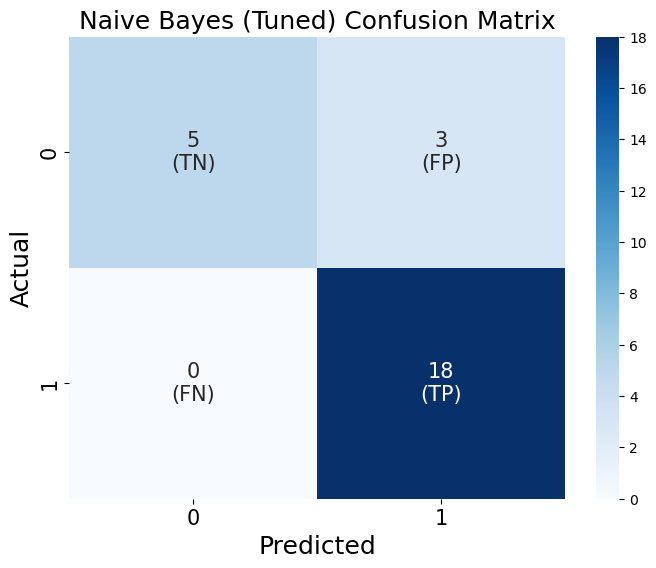

In [162]:
# Predict on the test set
y_pred = best_NB.predict(X_test)
y_pred_proba = best_NB.predict_proba(X_test)[:, 1]

# Evaluation metrics
NB_rand_accuracy = accuracy_score(y_test, y_pred)
NB_rand_precision = precision_score(y_test, y_pred)
NB_rand_recall = recall_score(y_test, y_pred)
NB_rand_f1 = f1_score(y_test, y_pred)
NB_rand_roc_auc = roc_auc_score(y_test, y_pred_proba)
NB_rand_conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {NB_rand_accuracy}')
print(f'Precision: {NB_rand_precision}')
print(f'Recall: {NB_rand_recall}')
print(f'F1 Score: {NB_rand_f1}')
print(f'ROC-AUC Score: {NB_rand_roc_auc}')
print(f'Confusion Matrix:\n{NB_rand_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{NB_rand_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(NB_rand_conf_matrix.shape[1])] 
                              for i in range(NB_rand_conf_matrix.shape[0])])

value, counts = np.unique(y_test, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(NB_rand_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Naive Bayes (Tuned) Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

## Support Vector Machine

SVM Model Cross-validation average score: 0.7654545454545455
Accuracy: 0.6923076923076923
Precision: 0.6923076923076923
Recall: 1.0
F1 Score: 0.8181818181818181
ROC-AUC Score: 0.9583333333333333
Confusion Matrix:
[[ 0  8]
 [ 0 18]]


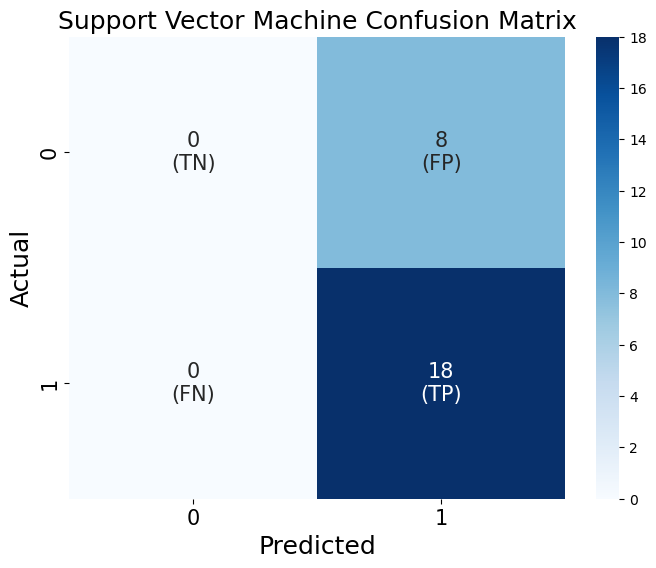

In [163]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42)

SVM_Model = SVC(probability=True)

SVM_cross_scores = cross_val_score(SVM_Model, X_train, y_train, cv=10)
print(f'SVM Model Cross-validation average score: {SVM_cross_scores.mean()}')

# Train the model
SVM_Model.fit(X_train, y_train)

# Predict on the test set
y_pred = SVM_Model.predict(X_test)
y_pred_proba = SVM_Model.predict_proba(X_test)[:, 1]

# Evaluation metrics
SVM_accuracy = accuracy_score(y_test, y_pred)
SVM_precision = precision_score(y_test, y_pred)
SVM_recall = recall_score(y_test, y_pred)
SVM_f1 = f1_score(y_test, y_pred)
SVM_roc_auc = roc_auc_score(y_test, y_pred_proba)
SVM_conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {SVM_accuracy}')
print(f'Precision: {SVM_precision}')
print(f'Recall: {SVM_recall}')
print(f'F1 Score: {SVM_f1}')
print(f'ROC-AUC Score: {SVM_roc_auc}')
print(f'Confusion Matrix:\n{SVM_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{SVM_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(SVM_conf_matrix.shape[1])] 
                              for i in range(SVM_conf_matrix.shape[0])])

value, counts = np.unique(y_test, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(SVM_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Support Vector Machine Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

### Randomized Search

In [164]:
print('Parameters currently in use:\n')
pprint(SVM_Model.get_params())

Parameters currently in use:

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': True,
 'random_state': None,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}


In [165]:
C = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

kernel = ['linear', 'rbf', 'poly', 'sigmoid']

gamma = ['scale', 'auto', 0.001, 0.01, 0.1, 1]

degree = [2, 3, 4, 5]

class_weight = [None, 'balanced']

probability = [True]

# Create the random grid
random_grid = {'C': C,
               'kernel': kernel,
               'gamma': gamma,
               'degree': degree,
               'class_weight': class_weight,
               'probability': probability}
pprint(random_grid)

{'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
 'class_weight': [None, 'balanced'],
 'degree': [2, 3, 4, 5],
 'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
 'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
 'probability': [True]}


In [166]:
SVM_random = RandomizedSearchCV(estimator = SVM_Model, param_distributions = random_grid, n_iter=50, cv = 5, scoring='accuracy', verbose=10, random_state=42, n_jobs = -1)
SVM_random.fit(X_train,y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 3/5; 1/50] START C=0.01, class_weight=None, degree=5, gamma=1, kernel=poly, probability=True[CV 2/5; 1/50] START C=0.01, class_weight=None, degree=5, gamma=1, kernel=poly, probability=True

[CV 4/5; 1/50] START C=0.01, class_weight=None, degree=5, gamma=1, kernel=poly, probability=True
[CV 1/5; 1/50] START C=0.01, class_weight=None, degree=5, gamma=1, kernel=poly, probability=True
[CV 2/5; 2/50] START C=0.01, class_weight=None, degree=4, gamma=1, kernel=rbf, probability=True
[CV 5/5; 1/50] START C=0.01, class_weight=None, degree=5, gamma=1, kernel=poly, probability=True
[CV 3/5; 2/50] START C=0.01, class_weight=None, degree=4, gamma=1, kernel=rbf, probability=True
[CV 1/5; 2/50] START C=0.01, class_weight=None, degree=4, gamma=1, kernel=rbf, probability=True
[CV 3/5; 1/50] END C=0.01, class_weight=None, degree=5, gamma=1, kernel=poly, probability=True;, score=0.900 total time=   2.3s
[CV 4/5; 1/50] END C=0.01, class_weig

RandomizedSearchCV(cv=5, estimator=SVC(probability=True), n_iter=50, n_jobs=-1,
                   param_distributions={'C': [0.001, 0.01, 0.1, 1, 10, 100,
                                              1000],
                                        'class_weight': [None, 'balanced'],
                                        'degree': [2, 3, 4, 5],
                                        'gamma': ['scale', 'auto', 0.001, 0.01,
                                                  0.1, 1],
                                        'kernel': ['linear', 'rbf', 'poly',
                                                   'sigmoid'],
                                        'probability': [True]},
                   random_state=42, scoring='accuracy', verbose=10)

In [167]:
SVM_random.best_params_

{'probability': True,
 'kernel': 'sigmoid',
 'gamma': 'scale',
 'degree': 2,
 'class_weight': None,
 'C': 100}

In [168]:
best_SVM = SVM_random.best_estimator_

Accuracy: 0.8846153846153846
Precision: 0.8571428571428571
Recall: 1.0
F1 Score: 0.923076923076923
ROC-AUC Score: 0.9861111111111112
Confusion Matrix:
[[ 5  3]
 [ 0 18]]


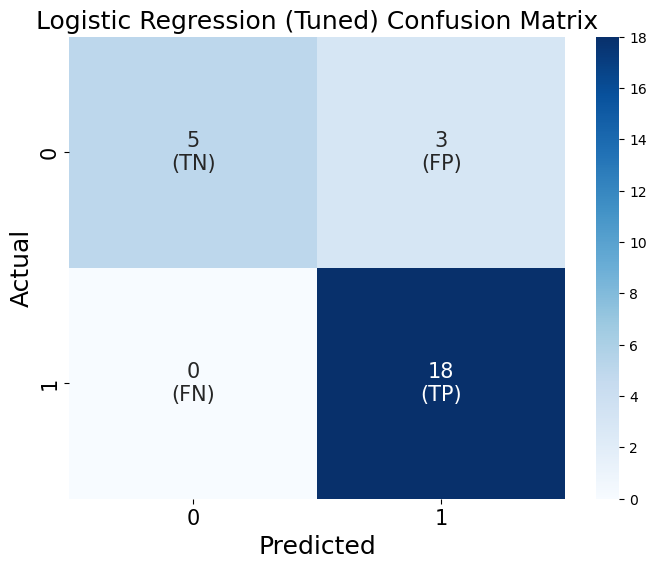

In [169]:
# Predict on the test set
y_pred = best_SVM.predict(X_test)
y_pred_proba = best_SVM.predict_proba(X_test)[:, 1]

# Evaluation metrics
SVM_rand_accuracy = accuracy_score(y_test, y_pred)
SVM_rand_precision = precision_score(y_test, y_pred)
SVM_rand_recall = recall_score(y_test, y_pred)
SVM_rand_f1 = f1_score(y_test, y_pred)
SVM_rand_roc_auc = roc_auc_score(y_test, y_pred_proba)
SVM_rand_conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {SVM_rand_accuracy}')
print(f'Precision: {SVM_rand_precision}')
print(f'Recall: {SVM_rand_recall}')
print(f'F1 Score: {SVM_rand_f1}')
print(f'ROC-AUC Score: {SVM_rand_roc_auc}')
print(f'Confusion Matrix:\n{SVM_rand_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{SVM_rand_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(SVM_rand_conf_matrix.shape[1])] 
                              for i in range(SVM_rand_conf_matrix.shape[0])])

value, counts = np.unique(y_test, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(SVM_rand_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Logistic Regression (Tuned) Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

## Validation

In [170]:
validation_df = pd.read_csv('data/reads/validation_exon_tpm', sep='\t').T


print(validation_df)
print(validation_df.shape)

            ENSG00000223972  ENSG00000227232  ENSG00000278267  \
BCSC_S5_01         0.000000         0.000000              0.0   
BCSC_S5_02         0.000000        10.710056              0.0   
BCSC_S5_03         0.000000         9.077035              0.0   
BCSC_S5_04         0.000000         0.000000              0.0   
BCSC_S5_05        14.462475         0.000000              0.0   
...                     ...              ...              ...   
BCSC_S6_71         0.000000         7.122692              0.0   
BCSC_S6_72         0.000000         0.000000              0.0   
BCSC_S6_73        13.779037         0.000000              0.0   
BCSC_S6_74         0.000000         0.000000              0.0   
BCSC_S6_75         0.000000         0.000000              0.0   

            ENSG00000243485  ENSG00000274890  ENSG00000237613  \
BCSC_S5_01         0.000000              0.0              0.0   
BCSC_S5_02         0.000000              0.0              0.0   
BCSC_S5_03         0.000

In [171]:
filtered_val_df = validation_df.loc[:, gene_mask]

print(filtered_val_df.shape)

(161, 43027)


In [172]:
bc_meta = pd.read_excel('data/validation_bc_meta.xlsx')
normal_meta = pd.read_excel('data/validation_normal_meta.xlsx')

print(bc_meta.head())

bc_samples = bc_meta["Mapping ID"]
normal_samples = normal_meta["Mapping ID"]

filtered_val_df["cancer_status"] = np.nan

filtered_val_df.loc[
    filtered_val_df.index.isin(bc_samples),
    "cancer_status"
] = 1

filtered_val_df.loc[
    filtered_val_df.index.isin(normal_samples),
    "cancer_status"
] = 0

filtered_val_df["cancer_status"] = filtered_val_df["cancer_status"].astype(int)

print(filtered_val_df)
print(filtered_val_df.shape)


   Mapping ID  Age at Sample collection  Gender  \
0  BCSC_S5_40                        29  Female   
1  BCSC_S5_41                        29  Female   
2  BCSC_S5_42                        33  Female   
3  BCSC_S5_43                        37  Female   
4  BCSC_S5_44                        39  Female   

  Recurrence Staus at the time of collection  
0                               Nonrecurrent  
1                               Nonrecurrent  
2                               Nonrecurrent  
3                               Nonrecurrent  
4                               Nonrecurrent  
            ENSG00000238009  ENSG00000233750  ENSG00000279457  \
BCSC_S5_01         3.928154         0.000000         0.000000   
BCSC_S5_02         0.000000         0.000000         0.000000   
BCSC_S5_03         0.000000         0.000000        18.561667   
BCSC_S5_04         8.481627         2.763426         0.000000   
BCSC_S5_05         0.000000         3.291237         6.330069   
...                  

/var/folders/y5/gxfz0jhs2t3_xl9dj050660m0000gn/T/ipykernel_23198/1975082748.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_val_df["cancer_status"] = np.nan
/var/folders/y5/gxfz0jhs2t3_xl9dj050660m0000gn/T/ipykernel_23198/1975082748.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_val_df["cancer_status"] = filtered_val_df["cancer_status"].astype(int)


In [173]:
X_val = filtered_val_df.drop(columns=["cancer_status"])
y_val = filtered_val_df["cancer_status"]

X_val = X_val[X.columns]

print((X_val.columns == X.columns).all())

X_val_scaled = scaler.fit_transform(X_val)

True


### Default

#### Logistic Regression

Accuracy: 0.5031055900621118
Precision: 0.5094339622641509
Recall: 0.9759036144578314
F1 Score: 0.6694214876033058
ROC-AUC Score: 0.6450417052826691
Confusion Matrix:
[[ 0 78]
 [ 2 81]]


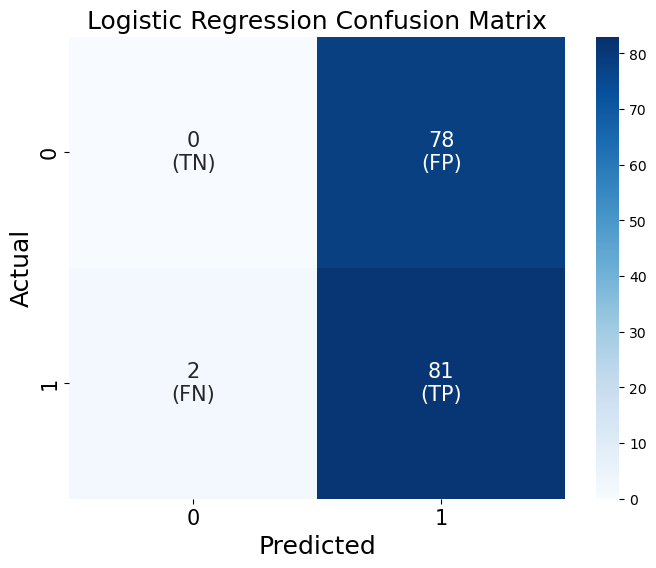

In [174]:
# Predict on the validation set
y_pred = LR_Model.predict(X_val_scaled)
y_pred_proba = LR_Model.predict_proba(X_val_scaled)[:, 1]

# Evaluation metrics
LR_accuracy = accuracy_score(y_val, y_pred)
LR_precision = precision_score(y_val, y_pred)
LR_recall = recall_score(y_val, y_pred)
LR_f1 = f1_score(y_val, y_pred)
LR_roc_auc = roc_auc_score(y_val, y_pred_proba)
LR_conf_matrix = confusion_matrix(y_val, y_pred)

print(f'Accuracy: {LR_accuracy}')
print(f'Precision: {LR_precision}')
print(f'Recall: {LR_recall}')
print(f'F1 Score: {LR_f1}')
print(f'ROC-AUC Score: {LR_roc_auc}')
print(f'Confusion Matrix:\n{LR_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{LR_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(LR_conf_matrix.shape[1])] 
                              for i in range(LR_conf_matrix.shape[0])])

value, counts = np.unique(y_val, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(LR_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Logistic Regression Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

#### Random Forest

Accuracy: 0.5031055900621118
Precision: 0.5096774193548387
Recall: 0.9518072289156626
F1 Score: 0.6638655462184874
ROC-AUC Score: 0.5990886623416743
Confusion Matrix:
[[ 2 76]
 [ 4 79]]


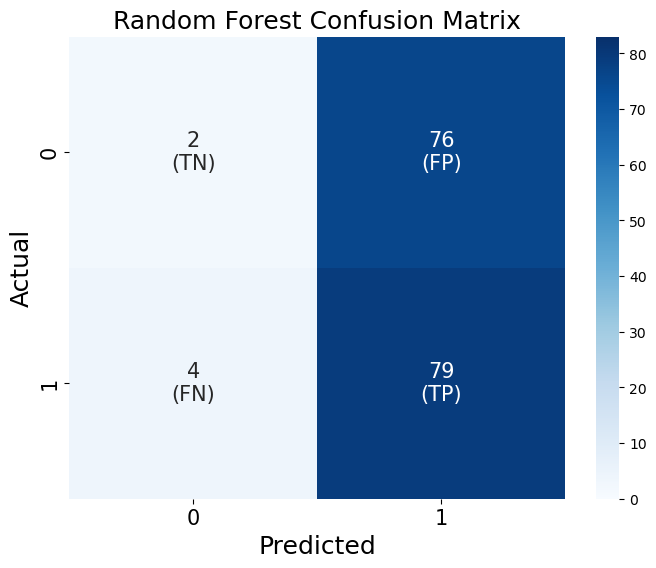

In [175]:
# Predict on the validation set
y_pred = RF_Model.predict(X_val_scaled)
y_pred_proba = RF_Model.predict_proba(X_val_scaled)[:, 1]

# Evaluation metrics
RF_accuracy = accuracy_score(y_val, y_pred)
RF_precision = precision_score(y_val, y_pred)
RF_recall = recall_score(y_val, y_pred)
RF_f1 = f1_score(y_val, y_pred)
RF_roc_auc = roc_auc_score(y_val, y_pred_proba)
RF_conf_matrix = confusion_matrix(y_val, y_pred)

print(f'Accuracy: {RF_accuracy}')
print(f'Precision: {RF_precision}')
print(f'Recall: {RF_recall}')
print(f'F1 Score: {RF_f1}')
print(f'ROC-AUC Score: {RF_roc_auc}')
print(f'Confusion Matrix:\n{RF_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{RF_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(RF_conf_matrix.shape[1])] 
                              for i in range(RF_conf_matrix.shape[0])])

value, counts = np.unique(y_val, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(RF_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Random Forest Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

#### Naive Bayes

Accuracy: 0.515527950310559
Precision: 0.515527950310559
Recall: 1.0
F1 Score: 0.680327868852459
ROC-AUC Score: 0.5
Confusion Matrix:
[[ 0 78]
 [ 0 83]]


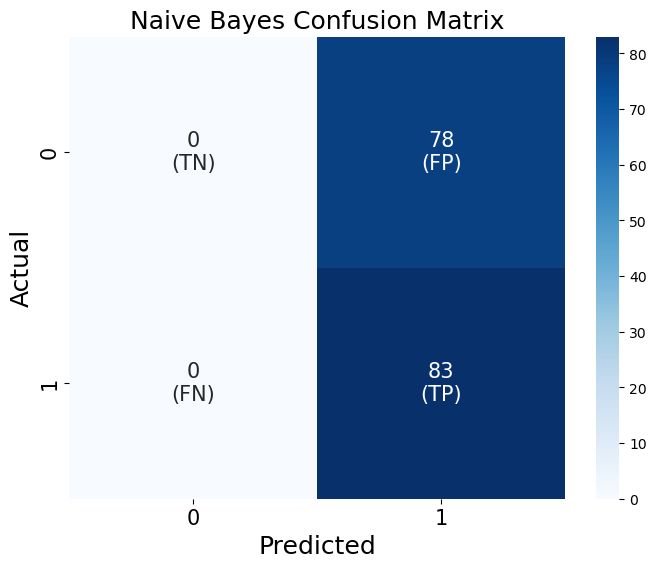

In [176]:
# Predict on the validation set
y_pred = NB_Model.predict(X_val_scaled)
y_pred_proba = NB_Model.predict_proba(X_val_scaled)[:, 1]

# Evaluation metrics
NB_accuracy = accuracy_score(y_val, y_pred)
NB_precision = precision_score(y_val, y_pred)
NB_recall = recall_score(y_val, y_pred)
NB_f1 = f1_score(y_val, y_pred)
NB_roc_auc = roc_auc_score(y_val, y_pred_proba)
NB_conf_matrix = confusion_matrix(y_val, y_pred)

print(f'Accuracy: {NB_accuracy}')
print(f'Precision: {NB_precision}')
print(f'Recall: {NB_recall}')
print(f'F1 Score: {NB_f1}')
print(f'ROC-AUC Score: {NB_roc_auc}')
print(f'Confusion Matrix:\n{NB_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{NB_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(NB_conf_matrix.shape[1])] 
                              for i in range(NB_conf_matrix.shape[0])])

value, counts = np.unique(y_val, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(NB_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Naive Bayes Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

#### Support Vector Machine

Accuracy: 0.515527950310559
Precision: 0.515527950310559
Recall: 1.0
F1 Score: 0.680327868852459
ROC-AUC Score: 0.6076614148903305
Confusion Matrix:
[[ 0 78]
 [ 0 83]]


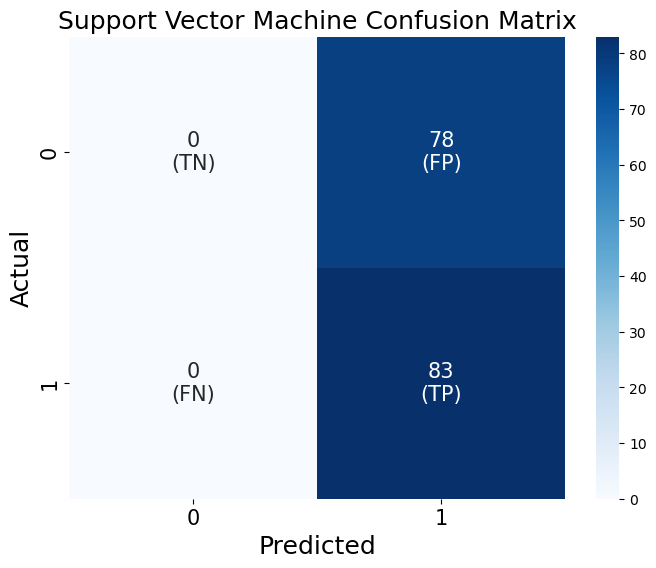

In [177]:
# Predict on the validation set
y_pred = SVM_Model.predict(X_val_scaled)
y_pred_proba = SVM_Model.predict_proba(X_val_scaled)[:, 1]

# Evaluation metrics
SVM_accuracy = accuracy_score(y_val, y_pred)
SVM_precision = precision_score(y_val, y_pred)
SVM_recall = recall_score(y_val, y_pred)
SVM_f1 = f1_score(y_val, y_pred)
SVM_roc_auc = roc_auc_score(y_val, y_pred_proba)
SVM_conf_matrix = confusion_matrix(y_val, y_pred)

print(f'Accuracy: {SVM_accuracy}')
print(f'Precision: {SVM_precision}')
print(f'Recall: {SVM_recall}')
print(f'F1 Score: {SVM_f1}')
print(f'ROC-AUC Score: {SVM_roc_auc}')
print(f'Confusion Matrix:\n{SVM_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{SVM_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(SVM_conf_matrix.shape[1])] 
                              for i in range(SVM_conf_matrix.shape[0])])

value, counts = np.unique(y_val, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(SVM_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Support Vector Machine Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

### Hyperparameter Tuned

#### Logistic Regression

Accuracy: 0.515527950310559
Precision: 0.5157232704402516
Recall: 0.9879518072289156
F1 Score: 0.6776859504132231
ROC-AUC Score: 0.6221810318195861
Confusion Matrix:
[[ 1 77]
 [ 1 82]]


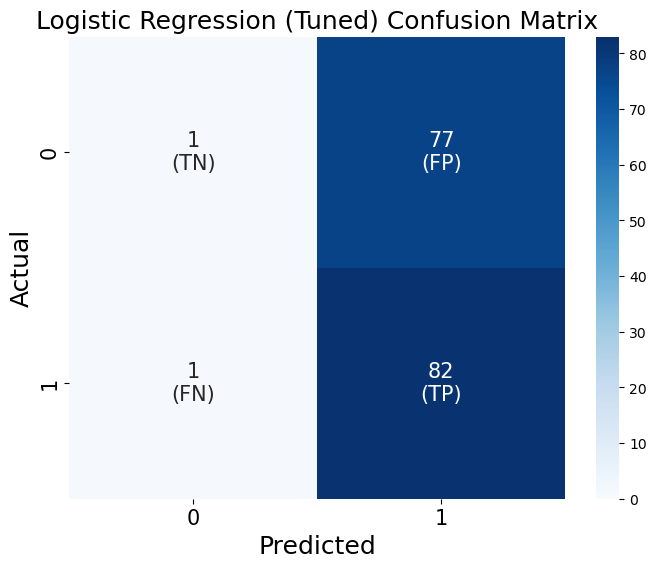

In [178]:
# Predict on the validation set
y_pred = best_LR.predict(X_val_scaled)
y_pred_proba = best_LR.predict_proba(X_val_scaled)[:, 1]

# Evaluation metrics
LR_rand_accuracy = accuracy_score(y_val, y_pred)
LR_rand_precision = precision_score(y_val, y_pred)
LR_rand_recall = recall_score(y_val, y_pred)
LR_rand_f1 = f1_score(y_val, y_pred)
LR_rand_roc_auc = roc_auc_score(y_val, y_pred_proba)
LR_rand_conf_matrix = confusion_matrix(y_val, y_pred)

print(f'Accuracy: {LR_rand_accuracy}')
print(f'Precision: {LR_rand_precision}')
print(f'Recall: {LR_rand_recall}')
print(f'F1 Score: {LR_rand_f1}')
print(f'ROC-AUC Score: {LR_rand_roc_auc}')
print(f'Confusion Matrix:\n{LR_rand_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{LR_rand_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(LR_rand_conf_matrix.shape[1])] 
                              for i in range(LR_rand_conf_matrix.shape[0])])

value, counts = np.unique(y_val, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(LR_rand_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Logistic Regression (Tuned) Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

#### Random Forest

Accuracy: 0.453416149068323
Precision: 0.4778761061946903
Recall: 0.6506024096385542
F1 Score: 0.5510204081632654
ROC-AUC Score: 0.5114303367315416
Confusion Matrix:
[[19 59]
 [29 54]]


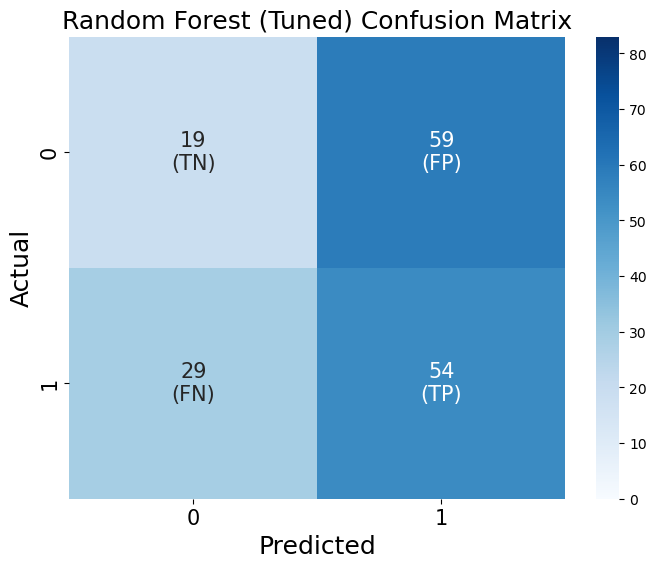

In [179]:
# Predict on the validation set
y_pred = best_RF.predict(X_val_scaled)
y_pred_proba = best_RF.predict_proba(X_val_scaled)[:, 1]

# Evaluation metrics
RF_rand_accuracy = accuracy_score(y_val, y_pred)
RF_rand_precision = precision_score(y_val, y_pred)
RF_rand_recall = recall_score(y_val, y_pred)
RF_rand_f1 = f1_score(y_val, y_pred)
RF_rand_roc_auc = roc_auc_score(y_val, y_pred_proba)
RF_rand_conf_matrix = confusion_matrix(y_val, y_pred)

print(f'Accuracy: {RF_rand_accuracy}')
print(f'Precision: {RF_rand_precision}')
print(f'Recall: {RF_rand_recall}')
print(f'F1 Score: {RF_rand_f1}')
print(f'ROC-AUC Score: {RF_rand_roc_auc}')
print(f'Confusion Matrix:\n{RF_rand_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{RF_rand_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(RF_rand_conf_matrix.shape[1])] 
                              for i in range(RF_rand_conf_matrix.shape[0])])

value, counts = np.unique(y_val, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(RF_rand_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Random Forest (Tuned) Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

#### Naive Bayes

Accuracy: 0.5093167701863354
Precision: 0.5125
Recall: 0.9879518072289156
F1 Score: 0.6748971193415637
ROC-AUC Score: 0.4939759036144578
Confusion Matrix:
[[ 0 78]
 [ 1 82]]


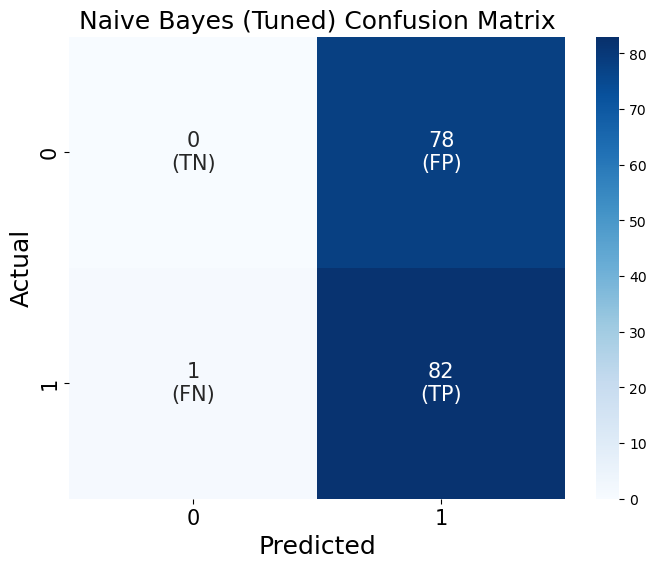

In [180]:
# Predict on the validation set
y_pred = best_NB.predict(X_val_scaled)
y_pred_proba = best_NB.predict_proba(X_val_scaled)[:, 1]

# Evaluation metrics
NB_rand_accuracy = accuracy_score(y_val, y_pred)
NB_rand_precision = precision_score(y_val, y_pred)
NB_rand_recall = recall_score(y_val, y_pred)
NB_rand_f1 = f1_score(y_val, y_pred)
NB_rand_roc_auc = roc_auc_score(y_val, y_pred_proba)
NB_rand_conf_matrix = confusion_matrix(y_val, y_pred)

print(f'Accuracy: {NB_rand_accuracy}')
print(f'Precision: {NB_rand_precision}')
print(f'Recall: {NB_rand_recall}')
print(f'F1 Score: {NB_rand_f1}')
print(f'ROC-AUC Score: {NB_rand_roc_auc}')
print(f'Confusion Matrix:\n{NB_rand_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{NB_rand_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(NB_rand_conf_matrix.shape[1])] 
                              for i in range(NB_rand_conf_matrix.shape[0])])

value, counts = np.unique(y_val, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(NB_rand_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Naive Bayes (Tuned) Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

#### Support Vector Machine

Accuracy: 0.5590062111801242
Precision: 0.5405405405405406
Recall: 0.963855421686747
F1 Score: 0.6926406926406926
ROC-AUC Score: 0.7730923694779116
Confusion Matrix:
[[10 68]
 [ 3 80]]


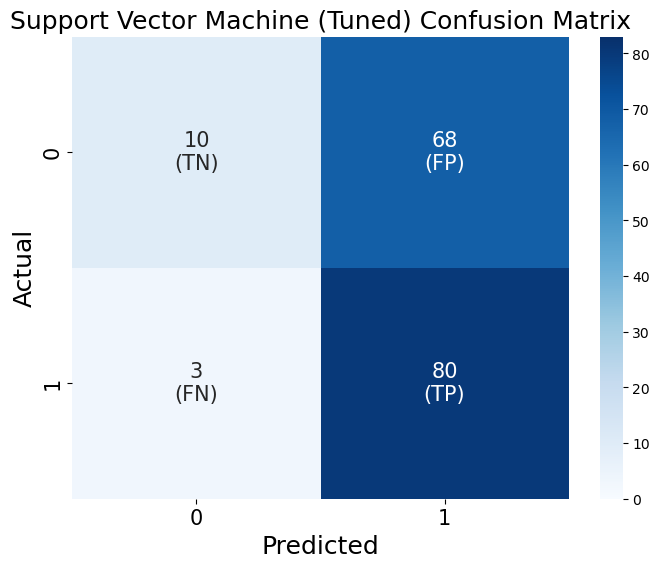

In [181]:
# Predict on the validation set
y_pred = best_SVM.predict(X_val_scaled)
y_pred_proba = best_SVM.predict_proba(X_val_scaled)[:, 1]

# Evaluation metrics
SVM_rand_accuracy = accuracy_score(y_val, y_pred)
SVM_rand_precision = precision_score(y_val, y_pred)
SVM_rand_recall = recall_score(y_val, y_pred)
SVM_rand_f1 = f1_score(y_val, y_pred)
SVM_rand_roc_auc = roc_auc_score(y_val, y_pred_proba)
SVM_rand_conf_matrix = confusion_matrix(y_val, y_pred)

print(f'Accuracy: {SVM_rand_accuracy}')
print(f'Precision: {SVM_rand_precision}')
print(f'Recall: {SVM_rand_recall}')
print(f'F1 Score: {SVM_rand_f1}')
print(f'ROC-AUC Score: {SVM_rand_roc_auc}')
print(f'Confusion Matrix:\n{SVM_rand_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{SVM_rand_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(SVM_rand_conf_matrix.shape[1])] 
                              for i in range(SVM_rand_conf_matrix.shape[0])])

value, counts = np.unique(y_val, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(SVM_rand_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Support Vector Machine (Tuned) Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

## Data Visualization

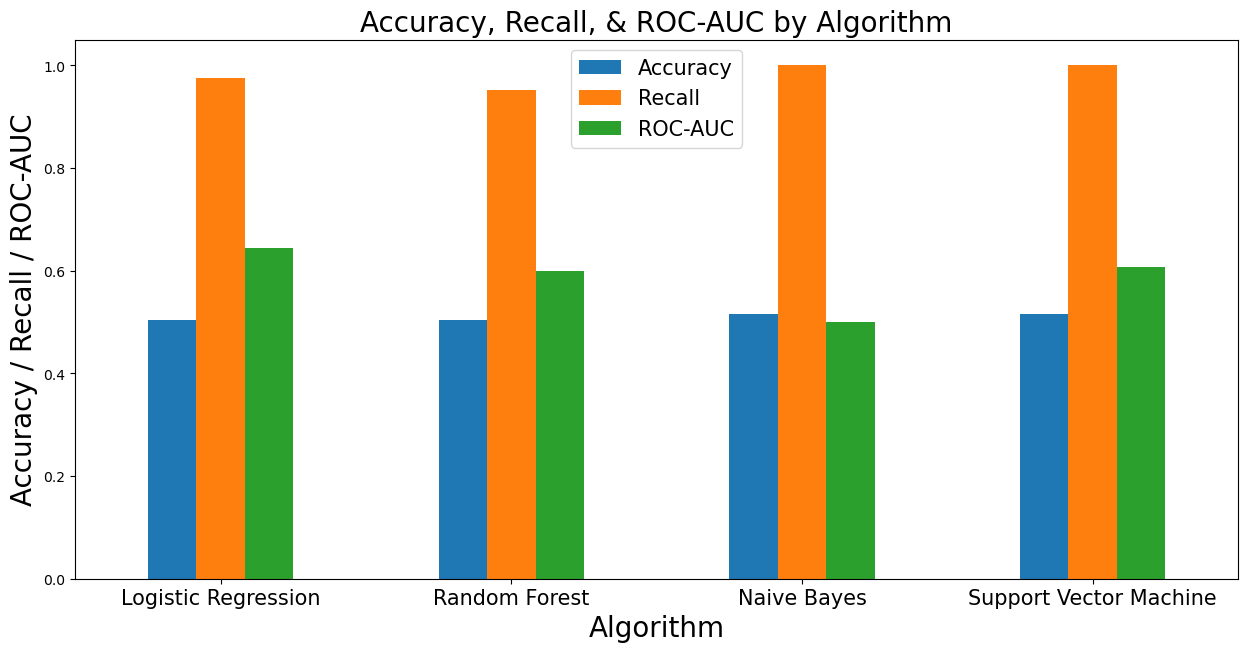

In [183]:
data = {
    "Logistic Regression": [
        LR_accuracy,
        LR_recall,
        LR_roc_auc,
    ],
    "Random Forest": [
        RF_accuracy,
        RF_recall,
        RF_roc_auc,
    ],
    "Naive Bayes": [
        NB_accuracy,
        NB_recall,
        NB_roc_auc,
    ],
    "Support Vector Machine": [
        SVM_accuracy,
        SVM_recall,
        SVM_roc_auc,
    ],
    
}

data_df = pd.DataFrame(data=data).T.reset_index().sort_values(by=[0], ascending=True)
data_df.columns = ["Algorithm", "Accuracy", "Recall", "ROC-AUC"]

# creating the bar plot
data_df.plot(kind="bar", x="Algorithm", y=["Accuracy", "Recall", "ROC-AUC"], figsize=(15, 7), rot=0)
plt.xlabel("Algorithm", fontsize=20)
plt.ylabel("Accuracy / Recall / ROC-AUC", fontsize=20)
plt.title("Accuracy, Recall, & ROC-AUC by Algorithm", fontsize=20)
plt.xticks(fontsize=15)
plt.legend(fontsize=15)

plt.show()

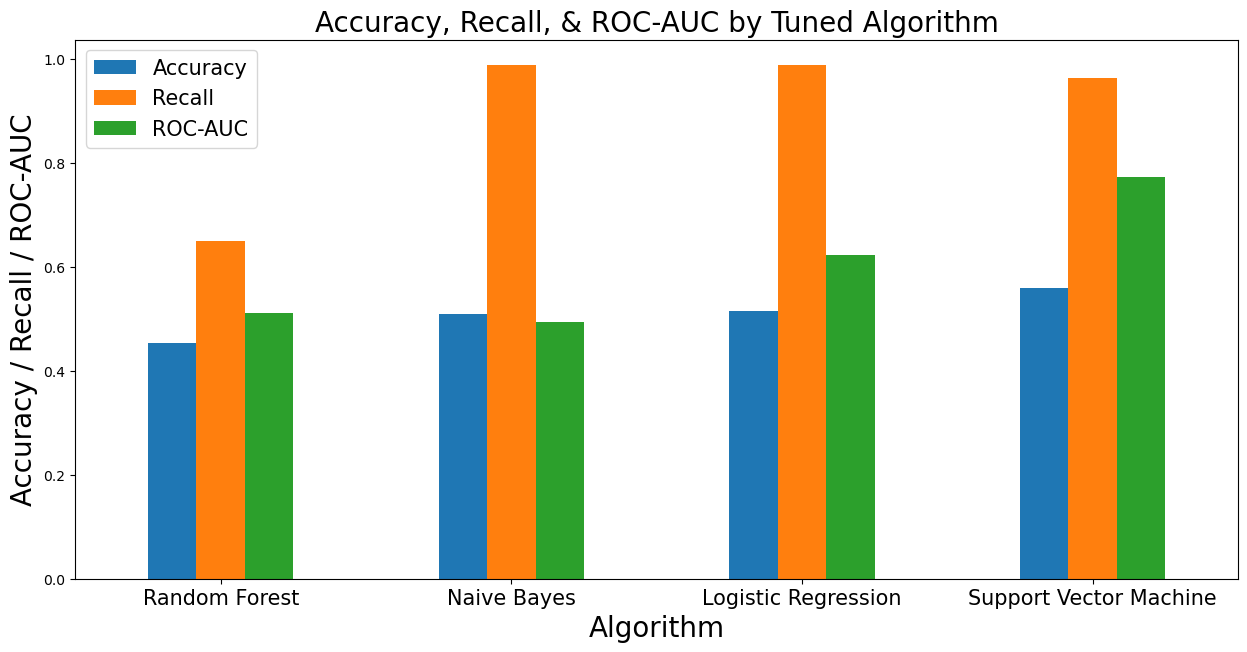

In [188]:
data = {
    "Logistic Regression": [
        LR_rand_accuracy,
        LR_rand_recall,
        LR_rand_roc_auc,
    ],
    "Random Forest": [
        RF_rand_accuracy,
        RF_rand_recall,
        RF_rand_roc_auc,
    ],
    "Naive Bayes": [
        NB_rand_accuracy,
        NB_rand_recall,
        NB_rand_roc_auc,
    ],
    "Support Vector Machine": [
        SVM_rand_accuracy,
        SVM_rand_recall,
        SVM_rand_roc_auc,
    ],
    
}

data_df = pd.DataFrame(data=data).T.reset_index().sort_values(by=[0], ascending=True)
data_df.columns = ["Algorithm", "Accuracy", "Recall", "ROC-AUC"]

# creating the bar plot
data_df.plot(kind="bar", x="Algorithm", y=["Accuracy", "Recall", "ROC-AUC"], figsize=(15, 7), rot=0)
plt.xlabel("Algorithm", fontsize=20)
plt.ylabel("Accuracy / Recall / ROC-AUC", fontsize=20)
plt.title("Accuracy, Recall, & ROC-AUC by Tuned Algorithm", fontsize=20)
plt.xticks(fontsize=15)
plt.legend(fontsize=15)

plt.show()

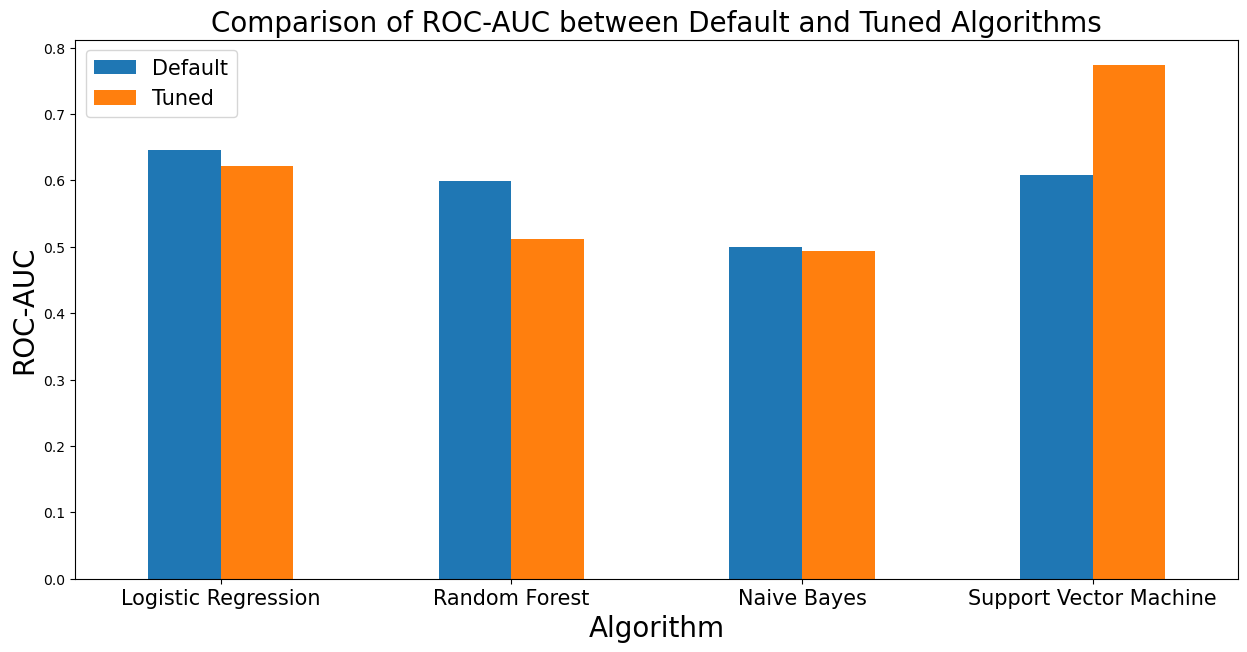

In [187]:
data = {
    "Logistic Regression": [
        LR_roc_auc,
        LR_rand_roc_auc,
    ],
    "Random Forest": [
        RF_roc_auc,
        RF_rand_roc_auc,
    ],
    "Naive Bayes": [
        NB_roc_auc,
        NB_rand_roc_auc,
    ],
    "Support Vector Machine": [
        SVM_roc_auc,
        SVM_rand_roc_auc,
    ],
    
}

data_df = pd.DataFrame(data=data).T.reset_index()
data_df.columns = ["Algorithm", "Default", "Tuned"]

# creating the bar plot
data_df.plot(kind="bar", x="Algorithm", y=["Default", "Tuned"], figsize=(15, 7), rot=0)
plt.xlabel("Algorithm", fontsize=20)
plt.ylabel("ROC-AUC", fontsize=20)
plt.title("Comparison of ROC-AUC between Default and Tuned Algorithms", fontsize=20)
plt.xticks(fontsize=15)
plt.legend(fontsize=15)

plt.show()

# Breast Cancer Gene Subset